### Initialization and Environment Setup

This cell initializes the AutoREACTER environment and prepares the working directory for the current run.

- `Initialization()` sets up the AutoREACTER runtime environment.
- `InputParser()` prepares the parser for validating and normalizing user input files.
- `GetCacheDir()` retrieves the staging cache directory used for intermediate data.
- `RunDirectoryManager.make_dated_run_dir()` creates a timestamped run directory to store outputs for this session.

In [1]:
from AutoREACTER.initialization import Initialization
from AutoREACTER.input_parser import InputParser
from AutoREACTER.cache import GetCacheDir, RunDirectoryManager, RetentionCleanup
from AutoREACTER.detectors.functional_groups_detector import FunctionalGroupsDetector
from AutoREACTER.detectors.reaction_detector import ReactionDetector
from AutoREACTER.detectors.non_monomer_detector import NonReactantsDetector
from AutoREACTER.reaction_preparation.reaction_processor.prepare_reactions import PrepareReactions
# from AutoREACTER.reaction_template_builder.run_reaction_template_pipeline import ReactionTemplatePipeline
from rdkit import Chem
from rdkit.Chem import Draw
import json

Initialization()
input_parser = InputParser()
cache_dir = GetCacheDir().staging_dir
dated_cache_dir = RunDirectoryManager.make_dated_run_dir(cache_dir, chdir_to="none")
# #future use
# RunDirectoryManager.copy_into_run(cache_dir, dated_cache_dir)
print(f"Cache directory: {cache_dir}")




All required modules are successfully imported.
                                                                                                                                                                                                                                                       
      .o.                       .                  ooooooooo.   oooooooooooo       .o.         .oooooo.   ooooooooooooo oooooooooooo ooooooooo.   
     .888.                    .o8                  `888   `Y88. `888'     `8      .888.       d8P'  `Y8b  8'   888   `8 `888'     `8 `888   `Y88. 
    .8"888.     oooo  oooo  .o888oo  .ooooo.        888   .d88'  888             .8"888.     888               888       888          888   .d88' 
   .8' `888.    `888  `888    888   d88' `88b       888ooo88P'   888oooo8       .8' `888.    888               888       888oooo8     888ooo88P'  
  .88ooo8888.    888   888    888   888   888       888`88b.     888    "      .88ooo8888.   888               888  

### Cache Cleanup (Optional)

This cell can be used to clean up cached data generated by previous runs.


In [2]:

# `RetentionCleanup.run()` removes cached directories from the AutoREACTER cache base directory.
#  Useful for freeing disk space or resetting the cache state.

# RetentionCleanup.run(GetCacheDir().cache_base_dir)

### Load and Validate Monomers

This cell loads the example input file, validates it using the `InputParser`, and visualizes the monomers.



In [3]:

# validate_inputs() checks the schema and normalizes the data.
# molecule_representation_of_initial_molecules() extracts RDKit molecule objects.
# Draw.MolsToGridImage() displays the monomers in a grid with their labels.

with open("example_1_inputs_count_mode.json", "r") as f:
    input_data = json.load(f)

validated_inputs = input_parser.validate_inputs(input_data)


### Visualize Monomers (Optional)

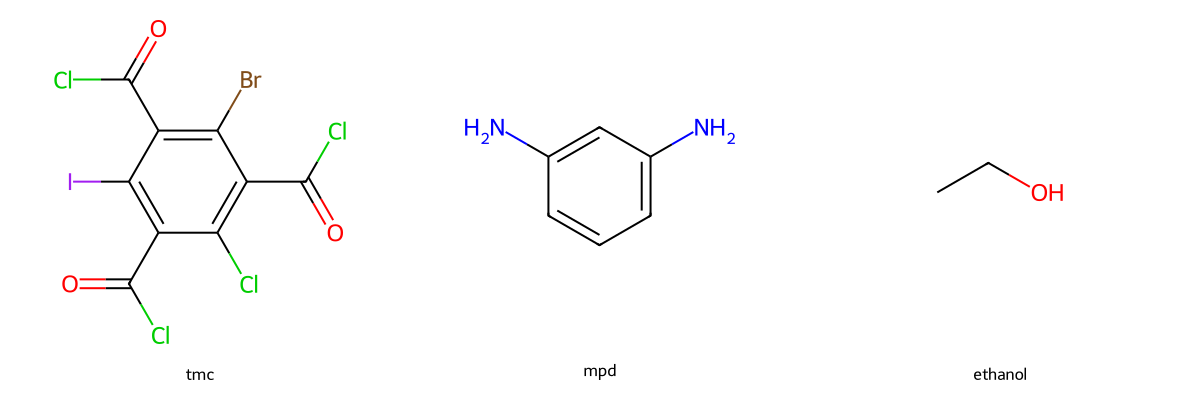

In [4]:
initial_molecules = input_parser.initial_molecules_image_grid(validated_inputs)
initial_molecules

### Cache Directory Information

This cell prints the default AutoREACTER cache directory.

In [5]:
default_cache_dir = GetCacheDir().cache_base_dir
print(f"Default cache directory: {default_cache_dir}")

Default cache directory: /mnt/c/Users/Janitha/Documents/AutoREACTER/cache


### Functional Group Detection

This cell runs the functional group detection step.


In [6]:
# FunctionalGroupsDetector() initializes the detector.
# functional_groups_detector() analyzes the validated monomers.
# It identifies functional groups present in each molecule and generates corresponding visualization images.

# Run the detector only after the inputs have been validated, as it consumes validated_inputs.monomers to execute the detection workflow.
functional_groups_detector = FunctionalGroupsDetector()
functional_groups, functional_groups_imgs = \
    functional_groups_detector.functional_groups_detector(
        validated_inputs.monomers
    )

O=C(Cl)c1c(Cl)c(C(=O)Cl)c(I)c(C(=O)Cl)c1Br has functionality: di_carboxylic_acid_halide
Nc1cccc(N)c1 has functionality: di_amine


### Functional Group Visualization (Optional)

This cell visualizes the detected functional groups on the molecules.

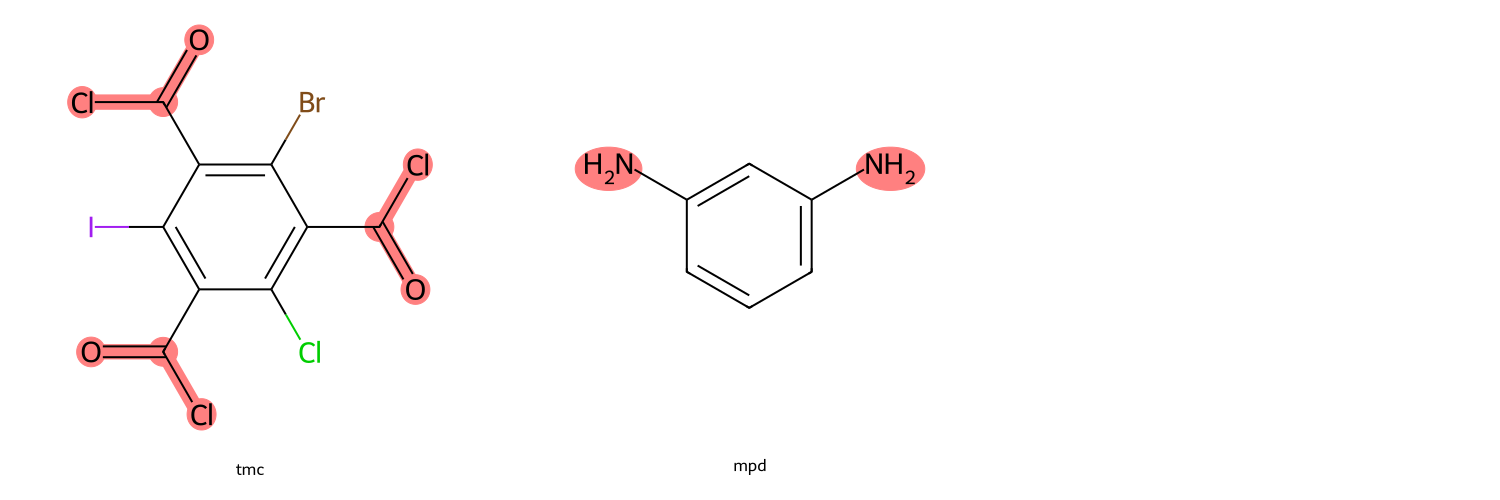

In [7]:
# molecules_to_visualization() highlights the functional groups identified in the previous step.
# The resulting image shows each molecule with the detected functional groups marked.

img = functional_groups_detector.functional_group_highlighted_molecules_image_grid(functional_groups_imgs)
img


### Reaction Detection

This cell identifies possible reactions between the detected functional groups.


In [8]:

# ReactionDetector() initializes the reaction detection module.
# reaction_detector() analyzes the detected functional groups and generates possible reaction instances.
# create_reaction_image_grid() visualizes the detected reactions in a grid format.

reaction_detector = ReactionDetector()
reaction_instances = reaction_detector.reaction_detector(functional_groups)


### Reaction visualization (Optional)

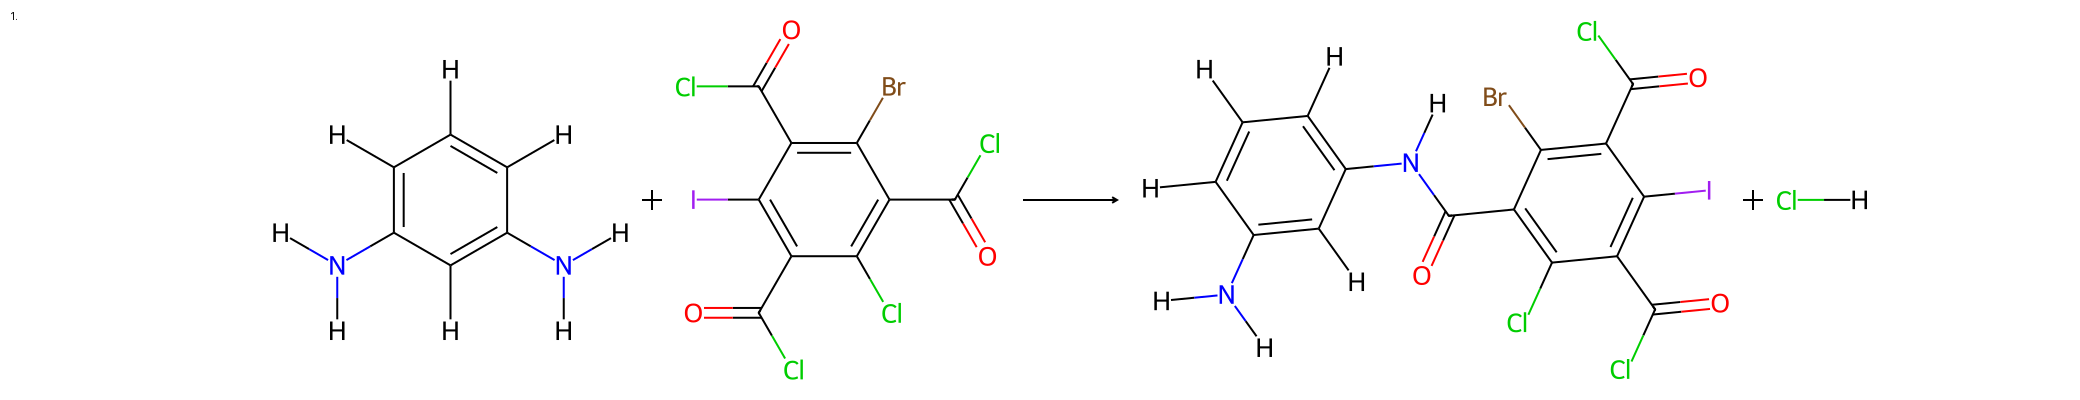

In [9]:
img = reaction_detector.available_reaction_image_grid(reaction_instances)
img

### Reaction Selection

This cell filters and selects the relevant reactions from the detected reaction instances.


In [10]:
# reaction_selection() processes the detected reactions.
# It removes user selected reactions from the list of detected reactions and returns the final set of reactions to be used for template generation.

selected_reactions = reaction_detector.reaction_selection(reaction_instances)

Only one reaction detected. Automatically selecting it.


In [11]:
print(selected_reactions)

[ReactionInstance(reaction_name='Di-Amine and Di-Carboxylic Acid Halide Polycondensation (Polyamidation)', reaction_smarts='[CX3:1](=[O:3])[Cl,Br,I:4].[N;H2,H1;!$(NC=*):2][H:5]>>[CX3:1](=[O:3])[NX3;!$(NC=*):2].[Cl,Br,I:4]([H:5])', delete_atom=True, references={'smarts': ['https://pubs.acs.org/doi/10.1021/acs.jcim.3c00329'], 'reaction_and_mechanism': ['https://pubs.acs.org/doi/10.1021/ed048pA734']}, same_reactants=False, monomer_1=MonomerRole(smiles='Nc1cccc(N)c1', name='mpd', functionalities=(FunctionalGroupInfo(functionality_type='di_identical', fg_name='di_amine', fg_smarts_1='[N&X3;H2,H1;!$(NC=*):3]', fg_count_1=2, fg_smarts_2=None, fg_count_2=None),)), functional_group_1=FunctionalGroupInfo(functionality_type='di_identical', fg_name='di_amine', fg_smarts_1='[N&X3;H2,H1;!$(NC=*):3]', fg_count_1=2, fg_smarts_2=None, fg_count_2=None), monomer_2=MonomerRole(smiles='O=C(Cl)c1c(Cl)c(C(=O)Cl)c(I)c(C(=O)Cl)c1Br', name='tmc', functionalities=(FunctionalGroupInfo(functionality_type='di_ident

### Non-Reactant (Non-Monomer) Detection

This cell identifies molecules that do **not participate in any detected reactions**.



In [12]:
# NonReactantsDetector() initializes the detector.
# non_monomer_detector() to determine which molecules are non-reactive.


non_monomer_detector = NonReactantsDetector()
non_reactants_list = non_monomer_detector.non_monomer_detector(validated_inputs, selected_reactions)


### non_reactants_to_visualization

ID: 3, Name: ethanol, SMILES: CCO


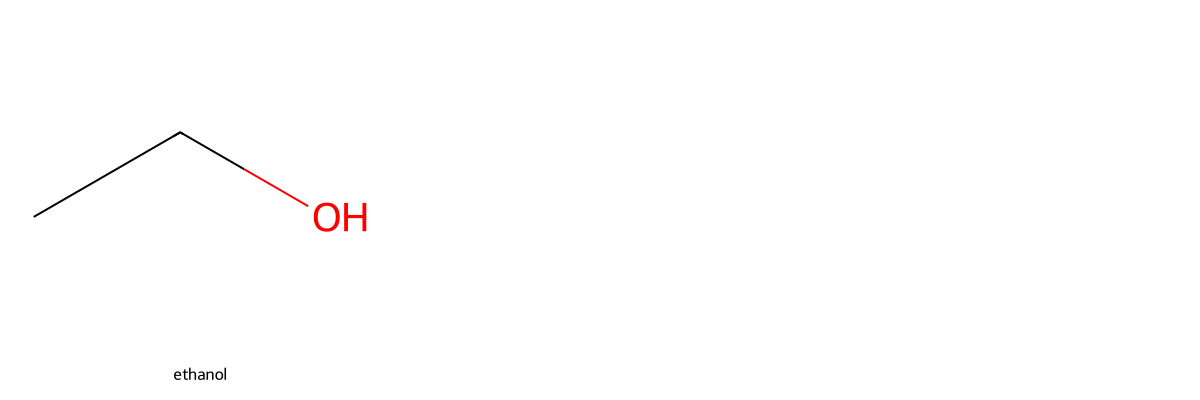

In [13]:
# `()` grid to non reactive molecules

# If no non-reactant molecules are detected, this stage is **automatically skipped**, and the workflow continues without generating any visualization.

img_non_reactants = non_monomer_detector.non_reactants_to_visualization(non_reactants_list)
img_non_reactants

### Update Inputs After Non-Reactant Filtering

This cell updates the validated inputs after identifying non-reactive molecules.


In [14]:
# non_reactant_selection() removes or marks molecules that do not participate in any reactions.
# The resulting `updated_inputs` contains the filtered set of monomers that will be used in the next stages of the workflow.
# If no non-reactants were detected in the previous step, the inputs remain unchanged.

updated_inputs = non_monomer_detector.non_reactant_selection(validated_inputs, non_reactants_list)


Selection Guide for Non-Reactant Monomers:
- N: Discard all non-reactant monomers from the simulation.
- A: Retain all non-reactant monomers in the simulation.
- S: Select specific non-reactant monomers to retain. You will be prompted 
to enter the IDs of the monomers you wish to keep, separated by commas.
Example: If you want to keep monomers with IDs 1 and 3, you would enter: 1,3
              
The following monomers do not participate in any detected reactions:
ID: 3, Name: ethanol, SMILES: CCO
Only one non-reactant monomer detected


In [15]:
prepare_reactions = PrepareReactions(cache_dir)
prepared_reactions = prepare_reactions.prepare_reactions(selected_reactions)

template_indexes: {1: [1, 0, 18, 2, 26], 2: [3, 19, 27], 3: [4, 16, 20, 25], 4: [5, 6, 12, 17, 21, 28, 23, 33]}
Edge atoms at max distance shell: [5, 6, 12, 17, 21, 28, 23, 33]
template_indexes: {1: [7, 8, 18, 9, 26], 2: [6, 19, 27], 3: [4, 10, 20, 25], 4: [3, 5, 11, 12, 21, 28, 23, 33]}
Edge atoms at max distance shell: [3, 5, 11, 12, 21, 28, 23, 33]
template_indexes: {1: [13, 14, 18, 15, 26], 2: [12, 19, 27], 3: [10, 16, 20, 25], 4: [6, 11, 17, 3, 21, 28, 23, 33]}
Edge atoms at max distance shell: [6, 11, 17, 3, 21, 28, 23, 33]


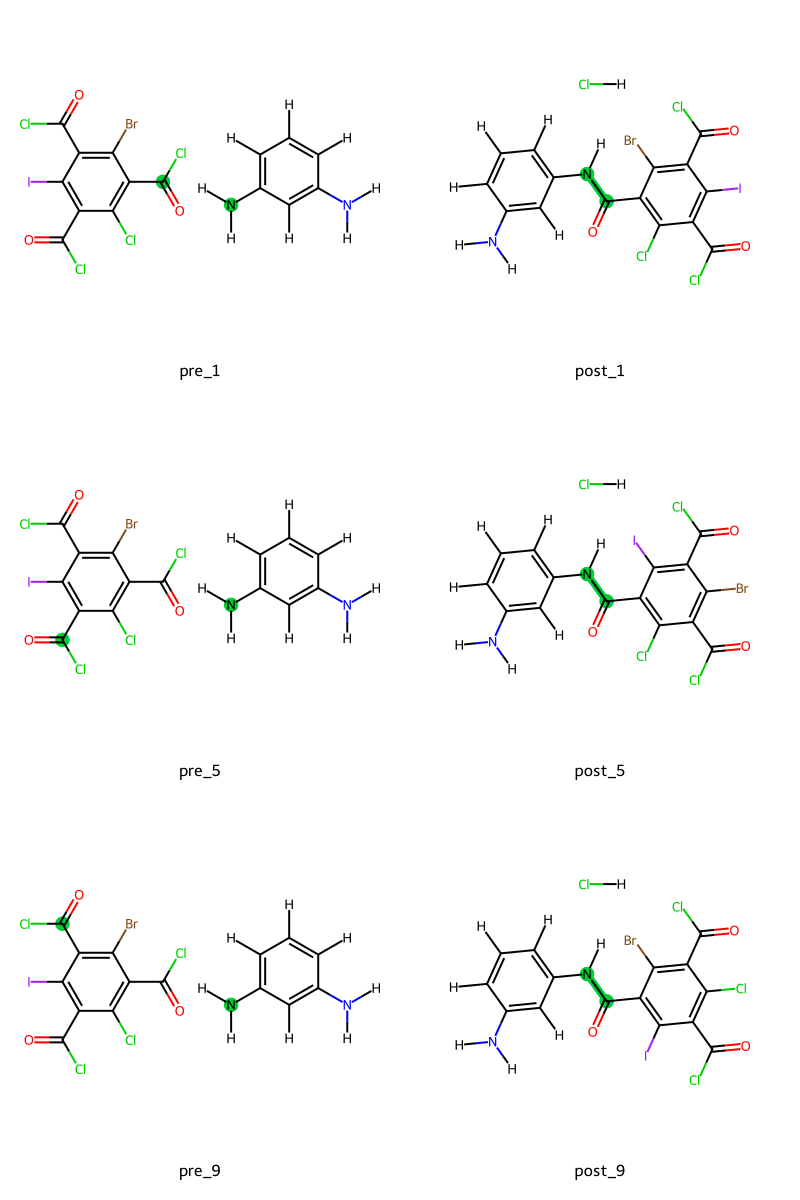

In [16]:
img = prepare_reactions.reaction_templates_highlighted_image_grid(prepared_reactions, highlight_type="initiators")
img

In [17]:
from AutoREACTER.reaction_preparation.lunar_client.molecule_3d_preparation import Molecule3DPreparation
from AutoREACTER.reaction_preparation.lunar_client.lunar_api_wrapper import LunarAPIWrapper
molecule3dpreparation = Molecule3DPreparation(cache_dir)
updated_inputs_with_3d_mols, prepared_reactions_with_3d_mols = molecule3dpreparation.prepare_molecule_3d_geometry(updated_inputs, prepared_reactions)
        

Saving optimized tmc to /mnt/c/Users/Janitha/Documents/AutoREACTER/cache/00_cache/3D_molecules/molecules_3Dmol/tmc.mol
Saving optimized mpd to /mnt/c/Users/Janitha/Documents/AutoREACTER/cache/00_cache/3D_molecules/molecules_3Dmol/mpd.mol
Saving optimized ethanol to /mnt/c/Users/Janitha/Documents/AutoREACTER/cache/00_cache/3D_molecules/molecules_3Dmol/ethanol.mol
Saving optimized pre_1 to /mnt/c/Users/Janitha/Documents/AutoREACTER/cache/00_cache/3D_molecules/full_templates_3Dmol/pre_1.mol
MMFF optimization failed for post_1.
Saving optimized post_1 to /mnt/c/Users/Janitha/Documents/AutoREACTER/cache/00_cache/3D_molecules/full_templates_3Dmol/post_1.mol
Saving optimized pre_5 to /mnt/c/Users/Janitha/Documents/AutoREACTER/cache/00_cache/3D_molecules/full_templates_3Dmol/pre_5.mol
MMFF optimization failed for post_5.
Saving optimized post_5 to /mnt/c/Users/Janitha/Documents/AutoREACTER/cache/00_cache/3D_molecules/full_templates_3Dmol/post_5.mol
Saving optimized pre_9 to /mnt/c/Users/Janith

[11:20:52] Molecule does not have explicit Hs. Consider calling AddHs()
[11:20:52] Molecule does not have explicit Hs. Consider calling AddHs()
[11:20:52] Molecule does not have explicit Hs. Consider calling AddHs()
[11:20:52] Molecule does not have explicit Hs. Consider calling AddHs()


In [18]:
from AutoREACTER.reaction_preparation.lunar_client.lunar_api_wrapper import LunarAPIWrapper
lunar_api_wrapper = LunarAPIWrapper(cache_dir)
lunar_api_wrapper.lunar_workflow(updated_inputs_with_3d_mols, prepared_reactions_with_3d_mols)

Using saved LUNAR root directory: /mnt/c/Users/Janitha/Documents/GitHub/LUNAR

        █████       █████  █████ ██████   █████   █████████   ███████████  
        ░░███       ░░███  ░░███ ░░██████ ░░███   ███░░░░░███ ░░███░░░░░███ 
        ░███        ░███   ░███  ░███░███ ░███  ░███    ░███  ░███    ░███ 
        ░███        ░███   ░███  ░███░░███░███  ░███████████  ░██████████  
        ░███        ░███   ░███  ░███ ░░██████  ░███░░░░░███  ░███░░░░░███ 
        ░███      █ ░███   ░███  ░███  ░░█████  ░███    ░███  ░███    ░███ 
        ███████████ ░░████████   █████  ░░█████ █████   █████ █████   █████
        ░░░░░░░░░░░   ░░░░░░░░   ░░░░░    ░░░░░ ░░░░░   ░░░░░ ░░░░░   ░░░░░ 
        
Loading LUNAR API Wrapper Initialization\
Ready!


Command line run option override checks (will warn if command line run option is used but not all options are provided at the command line):
WARNING override option   -bond              not provided at the command line. Hard coded input being enforced

TypeError: expected str, bytes or os.PathLike object, not bool

In [ ]:
from pathlib import Path

with open(Path(cache_dir) / "output.txt", "w") as f:
    f.write(captured_output.stdout)

print(f"Output written to {Path(cache_dir) / 'output.txt'}")


NameError: name 'captured_output' is not defined